In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
import warnings
warnings.filterwarnings('ignore')

In [2]:

df_decl = pd.read_csv(r"../dataset/disaster_declarations.csv")
df_funding = pd.read_csv(r"../dataset/pa_funding_details.csv")

In [13]:
print(f"Shape Of Disaster Declarations Dataset: {df_decl.shape}")
df_decl.head()

Shape Of Disaster Declarations Dataset: (69769, 12)


,disasterNumber,state,designatedArea,incidentType,declarationDate,incidentBeginDate,incidentEndDate,declarationType,ihProgramDeclared,iaProgramDeclared,paProgramDeclared,hmProgramDeclared
0,5529,OR,Washington (County),Fire,2024-08-09T00:00:00.000Z,2024-08-08T00:00:00.000Z,NaN,FM,0,0,1,1
1,5528,OR,Jefferson (County),Fire,2024-08-06T00:00:00.000Z,2024-08-04T00:00:00.000Z,NaN,FM,0,0,1,1
2,5527,OR,Deschutes (County),Fire,2024-08-02T00:00:00.000Z,2024-08-02T00:00:00.000Z,NaN,FM,0,0,1,1
3,4312,CA,Resighini Rancheria (Indian Reservation),Severe Storm,2017-05-02T00:00:00.000Z,2017-02-08T00:00:00.000Z,2017-02-11T00:00:00.000Z,DR,0,0,1,1
4,4251,AL,Autauga (County),Severe Storm,2016-01-21T00:00:00.000Z,2015-12-23T00:00:00.000Z,2015-12-31T00:00:00.000Z,DR,0,0,1,1


In [12]:
print(f"Shape Of Public Assistance Funding Dataset: {df_funding.shape}")
df_funding.head()

Shape Of Public Assistance Funding Dataset: (784941, 7)


,disasterNumber,stateAbbreviation,projectSize,damageCategoryCode,projectAmount,federalShareObligated,totalObligated
0,1603,LA,Large,E,18602329.78,18602329.78,18788818.15
1,1586,AZ,Large,G,112090.72,84068.04,88196.37
2,1586,AZ,Large,G,773645.98,580234.49,603034.89
3,3384,PR,Small,B,59779.98,44834.99,44834.99
4,3384,PR,Small,B,20333.13,15249.85,15249.85


In [14]:
# 1. Check for disasterNumber duplicates in declarations (the supposed Primary Key table)
decl_dupes_count = df_decl.duplicated(subset=['disasterNumber']).sum()

# Check for duplicate rows in public funding 
funding_dupes_count = df_funding.duplicated().sum()

# 2. Check for disasters in funding that ARE NOT in declarations
funding_ids = set(df_funding['disasterNumber'].unique())
decl_ids = set(df_decl['disasterNumber'].unique())
orphans = funding_ids - decl_ids

# 3. See a sample of the duplicates in declarations to see why they exist
sample_decl_dupes = df_decl[df_decl.duplicated(subset=['disasterNumber'], keep=False)].sort_values('disasterNumber').head()

print(f"Rows in Declarations with duplicate 'disasterNumber': {decl_dupes_count}")
print(f"Duplicated rows in Public Funding: {funding_dupes_count}")
print(f"Disaster IDs in Funding missing from Declarations: {len(orphans)}")
print(f"\n--- SAMPLE DUPLICATES IN DECLARATIONS ---")
sample_decl_dupes

Rows in Declarations with duplicate 'disasterNumber': 64606
Duplicated rows in Public Funding: 12425
Disaster IDs in Funding missing from Declarations: 0

--- SAMPLE DUPLICATES IN DECLARATIONS ---


,disasterNumber,state,designatedArea,incidentType,declarationDate,incidentBeginDate,incidentEndDate,declarationType,ihProgramDeclared,iaProgramDeclared,paProgramDeclared,hmProgramDeclared
69593,183,CA,Yuba (County),Flood,1964-12-24T00:00:00.000Z,1964-12-24T00:00:00.000Z,1964-12-24T00:00:00.000Z,DR,0,1,1,0
69592,183,CA,Yolo (County),Flood,1964-12-24T00:00:00.000Z,1964-12-24T00:00:00.000Z,1964-12-24T00:00:00.000Z,DR,0,1,1,0
69591,183,CA,Tuolumne (County),Flood,1964-12-24T00:00:00.000Z,1964-12-24T00:00:00.000Z,1964-12-24T00:00:00.000Z,DR,0,1,1,0
69590,183,CA,Trinity (County),Flood,1964-12-24T00:00:00.000Z,1964-12-24T00:00:00.000Z,1964-12-24T00:00:00.000Z,DR,0,1,1,0
69589,183,CA,Tehama (County),Flood,1964-12-24T00:00:00.000Z,1964-12-24T00:00:00.000Z,1964-12-24T00:00:00.000Z,DR,0,1,1,0


In [24]:
sample_funding_dupes = df_funding[df_funding.duplicated(keep=False)].sort_values(list(df_funding.columns)).head(6)
sample_funding_dupes

,disasterNumber,stateAbbreviation,projectSize,damageCategoryCode,projectAmount,federalShareObligated,totalObligated
139290,1310,KY,Small,C,1971.64,1478.73,1533.35
139292,1310,KY,Small,C,1971.64,1478.73,1533.35
142588,1310,KY,Small,C,3923.04,2942.28,3050.95
142591,1310,KY,Small,C,3923.04,2942.28,3050.95
141965,1316,AK,Small,E,5000.00,3750.00,3919.50
143952,1316,AK,Small,E,5000.00,3750.00,3919.50


In [54]:
df_decl['disasterNumber'].nunique()

5163

In [48]:
df_decl.isna().sum()

disasterNumber         0
state                  0
designatedArea         0
incidentType           0
declarationDate        0
incidentBeginDate      0
incidentEndDate      537
declarationType        0
ihProgramDeclared      0
iaProgramDeclared      0
paProgramDeclared      0
hmProgramDeclared      0
dtype: int64

#### Fill in the missing incidentEndDate using the median duration of each incidentType

In [ ]:

# 1. Ensure columns are in datetime format
df_decl['incidentBeginDate'] = pd.to_datetime(df_decl['incidentBeginDate'])
df_decl['incidentEndDate'] = pd.to_datetime(df_decl['incidentEndDate'])

# 2. Calculate existing durations (in days)
# We only calculate this for rows where both dates exist
df_decl['temp_duration'] = (df_decl['incidentEndDate'] - df_decl['incidentBeginDate']).dt.days

# 3. Calculate the Median Duration per Incident Type
# This creates a mapping: e.g., {'Flood': 12, 'Hurricane': 5}
median_durations = df_decl.groupby('incidentType')['temp_duration'].median()

# 4. Create a "Fallback" Duration
# For rows with missing end dates, look up the median for their incidentType
df_decl['inferred_duration_days'] = df_decl['incidentType'].map(median_durations)

# 5. Fill only the missing end dates
# We add the inferred days back to the start date as a Timedelta
mask = df_decl['incidentEndDate'].isna()
df_decl.loc[mask, 'incidentEndDate'] = (
    df_decl.loc[mask, 'incidentBeginDate'] + 
    pd.to_timedelta(df_decl.loc[mask, 'inferred_duration_days'], unit='D')
)

# 6. Cleanup: Drop the helper columns and format back to simple date if desired
df_decl = df_decl.drop(columns=['temp_duration', 'inferred_duration_days'])

# Optional: Convert back to a clean string date format (YYYY-MM-DD)
# df_final['incidentEndDate'] = df_final['incidentEndDate'].dt.date

print(f"Remaining missing end dates: {df_decl['incidentEndDate'].isna().sum()}")


0
Remaining missing end dates: 0


In [56]:
df_decl.isna().sum()

disasterNumber       0
state                0
designatedArea       0
incidentType         0
declarationDate      0
incidentBeginDate    0
incidentEndDate      0
declarationType      0
ihProgramDeclared    0
iaProgramDeclared    0
paProgramDeclared    0
hmProgramDeclared    0
dtype: int64

In [51]:
df_decl['disasterNumber'].nunique()

5163

In [57]:
# 1. Drop the county-specific column so we can group the rest
df_decl_clean = df_decl.drop(columns=['designatedArea']).drop_duplicates()

# 2. Check if disasterNumber is now unique
is_unique = df_decl_clean['disasterNumber'].is_unique
new_row_count = len(df_decl_clean)

print(f"Is disasterNumber unique now? {is_unique}")
print(f"New rows in cleaned declarations: {new_row_count}")

# 3. If unique, try the merge
if is_unique:
    df_merged = pd.merge(df_funding, df_decl_clean, on='disasterNumber', how='left')
    print(f"Final merged row count: {len(df_merged)}")
    print(f"Cleaned declarations row count: {len(df_decl_clean)}")


Is disasterNumber unique now? False
New rows in cleaned declarations: 6330


In [58]:
# Find the disasters that still have more than one row
duplicate_ids = df_decl_clean[df_decl_clean.duplicated('disasterNumber', keep=False)]

# Show a few examples to see what columns are different
print("--- DISASTERS WITH MULTIPLE DE-DUPLICATED ROWS ---")
print(duplicate_ids.sort_values('disasterNumber').head(10))

# Check specifically which columns are causing the split
different_cols = []
for col in df_decl_clean.columns:
    if col != 'disasterNumber':
        # If any disaster has more than 1 unique value in this column, it's a cause
        if df_decl_clean.groupby('disasterNumber')[col].nunique().max() > 1:
            different_cols.append(col)

print(f"\nColumns causing the duplicates: {different_cols}")


--- DISASTERS WITH MULTIPLE DE-DUPLICATED ROWS ---
       disasterNumber state  incidentType           declarationDate  \
67032             368    MS  Severe Storm  1973-03-27T00:00:00.000Z   
67033             368    MS  Severe Storm  1973-03-27T00:00:00.000Z   
62910             392    OK  Severe Storm  1973-06-13T00:00:00.000Z   
62912             392    OK  Severe Storm  1973-06-13T00:00:00.000Z   
60897             574    AR       Tornado  1979-04-11T00:00:00.000Z   
60900             574    AR       Tornado  1979-04-11T00:00:00.000Z   
60892             575    TX       Tornado  1979-04-11T00:00:00.000Z   
60894             575    TX       Tornado  1979-04-11T00:00:00.000Z   
60850             577    MS  Severe Storm  1979-04-16T00:00:00.000Z   
60851             577    MS  Severe Storm  1979-04-16T00:00:00.000Z   

              incidentBeginDate           incidentEndDate declarationType  \
67032 1973-03-27 00:00:00+00:00 1973-03-27 00:00:00+00:00              DR   
67033 1973-03

In [59]:
# 1. Identify all columns except the disasterNumber
all_cols = df_decl_clean.columns.tolist()
flag_cols = ['ihProgramDeclared', 'iaProgramDeclared', 'paProgramDeclared', 'hmProgramDeclared']
# Other info columns that should be the same across duplicates
info_cols = [c for c in all_cols if c not in flag_cols and c != 'disasterNumber']

# 2. Group by disasterNumber and the info columns, then take the MAX of the flags
df_decl_final = df_decl_clean.groupby(['disasterNumber'] + info_cols, as_index=False)[flag_cols].max()

print(f"Is disasterNumber unique now? {df_decl_final['disasterNumber'].is_unique}")
print(f"Final row count for declarations: {len(df_decl_final)}")

# 3. Perform the merge again
df_merged = pd.merge(df_funding, df_decl_final, on='disasterNumber', how='left')
print(f"Final merged row count: {len(df_merged)}")


Is disasterNumber unique now? True
Final row count for declarations: 5163
Final merged row count: 784941


In [60]:
# Find which disasterNumbers are causing the row count to increase
counts = df_merged['disasterNumber'].value_counts()
funding_counts = df_funding['disasterNumber'].value_counts()

# Compare the counts
diff = counts - funding_counts
problem_ids = diff[diff > 0].index.tolist()

print(f"Disaster IDs causing the 6 extra rows: {problem_ids}")

# Look at those specific IDs in your CLEANED declarations table
print("\n--- Rows for these IDs in df_decl_final ---")
print(df_decl_final[df_decl_final['disasterNumber'].isin(problem_ids)])


Disaster IDs causing the 6 extra rows: []

--- Rows for these IDs in df_decl_final ---
Empty DataFrame
Columns: [disasterNumber, state, incidentType, declarationDate, incidentBeginDate, incidentEndDate, declarationType, ihProgramDeclared, iaProgramDeclared, paProgramDeclared, hmProgramDeclared]
Index: []


In [61]:
# 1. Check for NaNs in the join key
funding_nans = df_funding['disasterNumber'].isna().sum()
decl_nans = df_decl_final['disasterNumber'].isna().sum()

# 2. Check for exact duplicates in the funding table before merging
funding_dupes = df_funding.duplicated().sum()

print(f"Total rows in original funding: {len(df_funding)}")
print(f"NaNs in funding disasterNumber: {funding_nans}")
print(f"NaNs in declarations disasterNumber: {decl_nans}")
print(f"Exact duplicate rows in funding: {funding_dupes}")

# 3. Try a different way to find the row expansion
# We merge and then check which original index was duplicated
df_funding_indexed = df_funding.copy()
df_funding_indexed['temp_index'] = range(len(df_funding_indexed))

df_check = pd.merge(df_funding_indexed, df_decl_final, on='disasterNumber', how='left')
expanded_rows = df_check[df_check.duplicated('temp_index', keep=False)]

print(f"\nRows that were duplicated during merge: {len(expanded_rows)}")
if len(expanded_rows) > 0:
    print(expanded_rows[['temp_index', 'disasterNumber']].head(10))


Total rows in original funding: 784941
NaNs in funding disasterNumber: 0
NaNs in declarations disasterNumber: 0
Exact duplicate rows in funding: 12425

Rows that were duplicated during merge: 0


In [62]:
# 1. Remove the exact duplicates from the funding side
df_funding_clean = df_funding.drop_duplicates()
print(f"Rows after removing duplicates: {len(df_funding_clean)}")

# 2. Re-run the merge with the CLEAN funding data
df_final = pd.merge(df_funding_clean, df_decl_final, on='disasterNumber', how='left')

# 3. Quick check: Total funding by State (Top 5)
# Replace 'totalObligatedAmount' with your actual money column name
money_col = 'totalObligatedAmount' 

if money_col in df_final.columns:
    top_states = df_final.groupby('state')[money_col].sum().sort_values(ascending=False).head(5)
    print("\n--- TOP 5 STATES BY TOTAL FUNDING ---")
    print(top_states)
else:
    print(f"\nAvailable columns for analysis: {df_final.columns.tolist()}")


Rows after removing duplicates: 772516

Available columns for analysis: ['disasterNumber', 'stateAbbreviation', 'projectSize', 'damageCategoryCode', 'projectAmount', 'federalShareObligated', 'totalObligated', 'state', 'incidentType', 'declarationDate', 'incidentBeginDate', 'incidentEndDate', 'declarationType', 'ihProgramDeclared', 'iaProgramDeclared', 'paProgramDeclared', 'hmProgramDeclared']


In [63]:
import pandas as pd

# 1. Total Funding by Incident Type (e.g., Flood vs. Fire)
incident_summary = df_final.groupby('incidentType')['totalObligated'].sum().sort_values(ascending=False)

# 2. Total Funding by State (Top 10)
state_summary = df_final.groupby('state')['totalObligated'].sum().sort_values(ascending=False).head(10)

# 3. Average Federal Share Percentage
# This helps see how much of the bill FEMA is picking up vs the state
df_final['fed_share_pct'] = (df_final['federalShareObligated'] / df_final['totalObligated']) * 100
avg_fed_share = df_final['fed_share_pct'].mean()

print("--- TOP 5 INCIDENT TYPES BY TOTAL FUNDING ---")
print(incident_summary.head(5))

print("\n--- TOP 5 STATES BY TOTAL FUNDING ---")
print(state_summary.head(5))

print(f"\nAverage Federal Share: {avg_fed_share:.2f}%")


--- TOP 5 INCIDENT TYPES BY TOTAL FUNDING ---
incidentType
Hurricane       1.350139e+11
Biological      9.362921e+10
Severe Storm    1.724151e+10
Fire            1.231793e+10
Flood           8.866765e+09
Name: totalObligated, dtype: float64

--- TOP 5 STATES BY TOTAL FUNDING ---
state
NY    4.093130e+10
PR    3.973501e+10
LA    2.616132e+10
CA    2.336438e+10
TX    2.249351e+10
Name: totalObligated, dtype: float64

Average Federal Share: nan%


In [64]:
# 1. Create a clean subset where totalObligated is greater than 0
df_money = df_final[df_final['totalObligated'] > 0].copy()

# 2. Recalculate Federal Share % safely
df_money['fed_share_pct'] = (df_money['federalShareObligated'] / df_money['totalObligated']) * 100

# 3. Format the output to Billions ($B)
incident_summary_bn = (df_money.groupby('incidentType')['totalObligated'].sum() / 1e9).sort_values(ascending=False)
state_summary_bn = (df_money.groupby('state')['totalObligated'].sum() / 1e9).sort_values(ascending=False)

print("--- FUNDING IN BILLIONS ($B) ---")
print(incident_summary_bn.head(5))
print(f"\nAverage Federal Share (Excl. Zeros): {df_money['fed_share_pct'].mean():.2f}%")

# 4. Check for 'Biological' (COVID) timing
df_money['year'] = pd.to_datetime(df_money['declarationDate']).dt.year
covid_check = df_money[df_money['incidentType'] == 'Biological'].groupby('year')['totalObligated'].sum() / 1e9
print("\n--- BIOLOGICAL FUNDING BY YEAR ($B) ---")
print(covid_check)


--- FUNDING IN BILLIONS ($B) ---
incidentType
Hurricane       135.034842
Biological       93.629214
Severe Storm     17.299664
Fire             12.698645
Flood             8.872364
Name: totalObligated, dtype: float64

Average Federal Share (Excl. Zeros): 98.72%

--- BIOLOGICAL FUNDING BY YEAR ($B) ---
year
2020    93.626776
2021     0.002439
Name: totalObligated, dtype: float64


## EDA

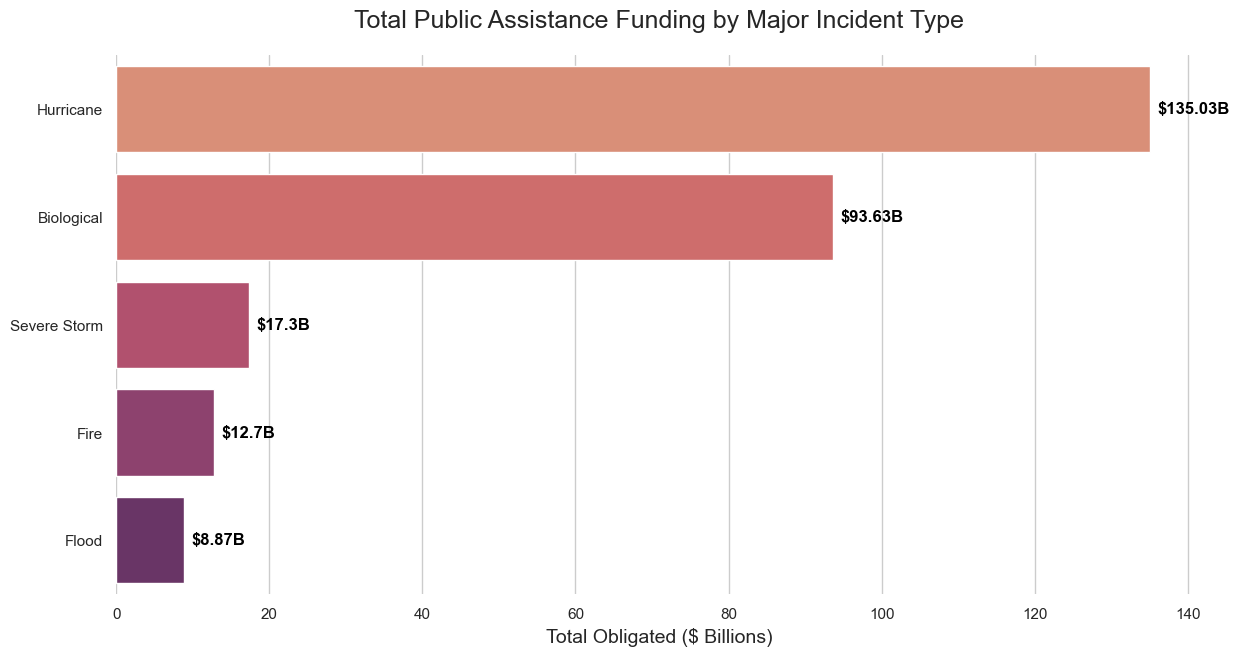

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional aesthetics
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

# Preparing your summary data in Billions
funding_data = {
    'Incident Type': ['Hurricane', 'Biological', 'Severe Storm', 'Fire', 'Flood'],
    'Total Obligated ($B)': [135.03, 93.63, 17.30, 12.70, 8.87]
}
df_plot = pd.DataFrame(funding_data)

# Create Bar Plot
ax = sns.barplot(data=df_plot, x='Total Obligated ($B)', y='Incident Type', palette='flare')

# Add values to the ends of bars
for i, v in enumerate(df_plot['Total Obligated ($B)']):
    ax.text(v + 1, i, f'${v}B', color='black', va='center', fontweight='bold')

plt.title('Total Public Assistance Funding by Major Incident Type', fontsize=18, pad=20)
plt.xlabel('Total Obligated ($ Billions)', fontsize=14)
plt.ylabel('')
sns.despine(left=True, bottom=True)
plt.show()


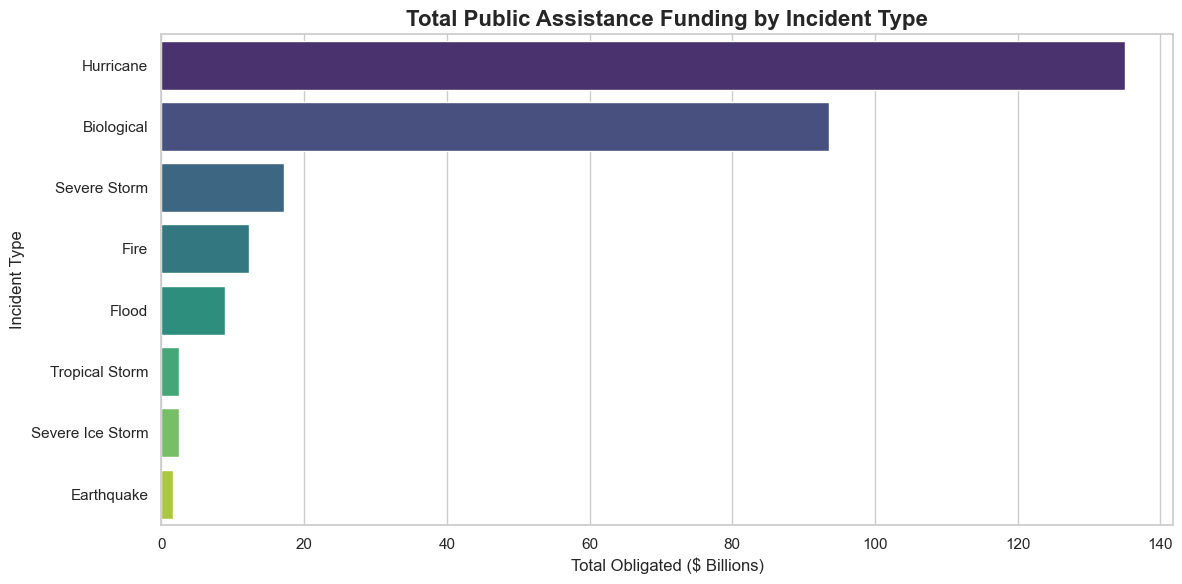

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional aesthetics
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Prepare data in Billions
incident_data = (df_final.groupby('incidentType')['totalObligated'].sum() / 1e9).sort_values(ascending=False).head(8)

sns.barplot(x=incident_data.values, y=incident_data.index, palette='viridis')
plt.title('Total Public Assistance Funding by Incident Type', fontsize=16, fontweight='bold')
plt.xlabel('Total Obligated ($ Billions)', fontsize=12)
plt.ylabel('Incident Type', fontsize=12)
plt.tight_layout()
plt.show()


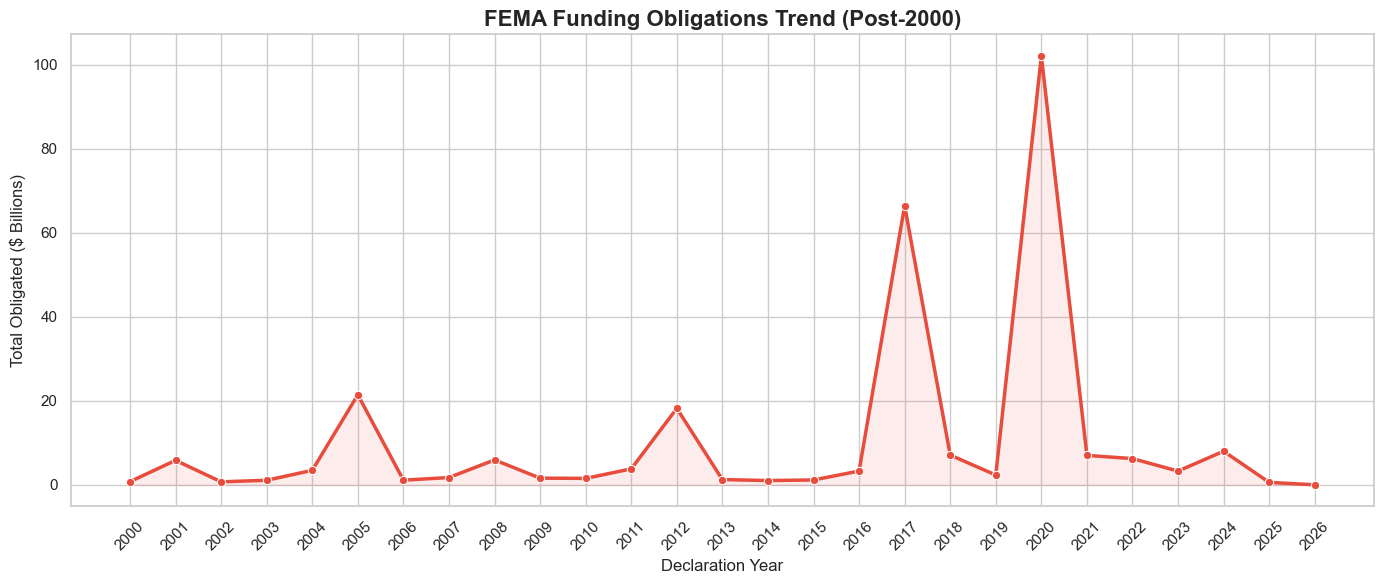

In [23]:
plt.figure(figsize=(14, 6))

# Convert to datetime and filter for recent history
df_final['dec_year'] = pd.to_datetime(df_final['declarationDate']).dt.year
yearly_funding = df_final[df_final['dec_year'] >= 2000].groupby('dec_year')['totalObligated'].sum() / 1e9

sns.lineplot(x=yearly_funding.index, y=yearly_funding.values, marker='o', color='#e74c3c', linewidth=2.5)
plt.fill_between(yearly_funding.index, yearly_funding.values, color='#e74c3c', alpha=0.1)

plt.title('FEMA Funding Obligations Trend (Post-2000)', fontsize=16, fontweight='bold')
plt.ylabel('Total Obligated ($ Billions)', fontsize=12)
plt.xlabel('Declaration Year', fontsize=12)
plt.xticks(yearly_funding.index, rotation=45)
plt.tight_layout()
plt.show()


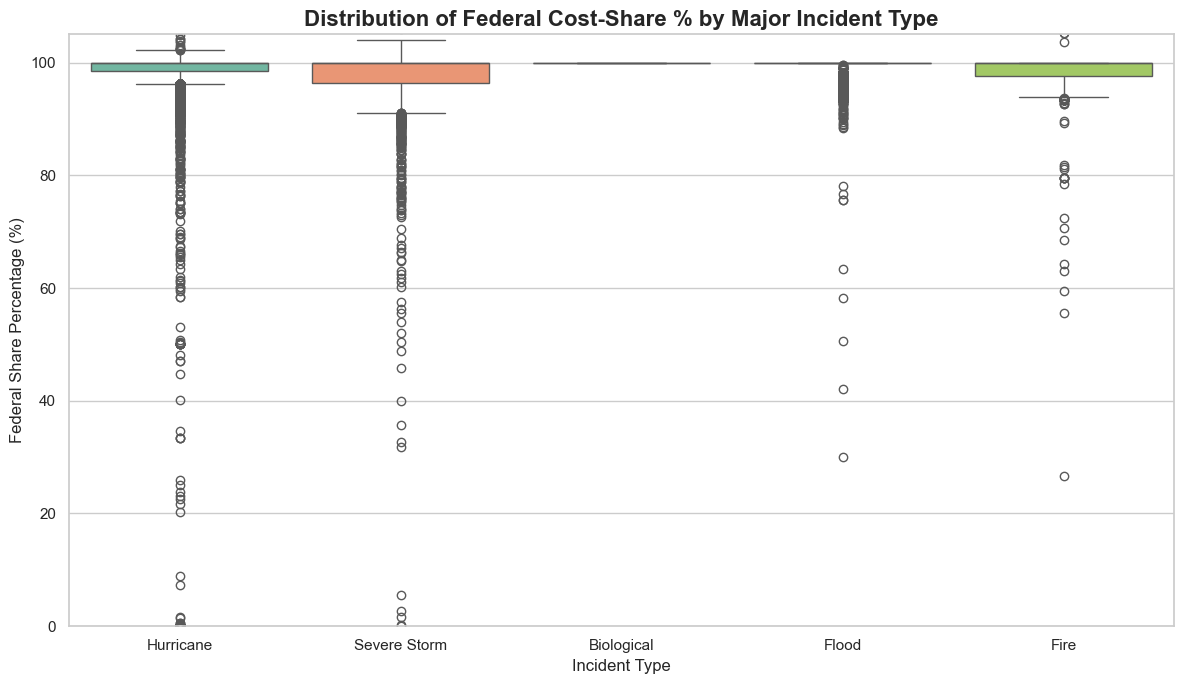

In [28]:
plt.figure(figsize=(12, 7))

# Filter for the top 5 incident types to keep the plot readable
top_5_types = df_final.groupby('incidentType')['totalObligated'].sum().nlargest(5).index
df_subset = df_final[(df_final['incidentType'].isin(top_5_types)) & (df_final['totalObligated'] > 0)].copy()
df_subset['fed_share_pct'] = (df_subset['federalShareObligated'] / df_subset['totalObligated']) * 100

sns.boxplot(data=df_subset, x='incidentType', y='fed_share_pct', palette='Set2')
plt.title('Distribution of Federal Cost-Share % by Major Incident Type', fontsize=16, fontweight='bold')
plt.ylabel('Federal Share Percentage (%)', fontsize=12)
plt.xlabel('Incident Type', fontsize=12)
plt.ylim(0, 105) # Cap at 100% (+ buffer)
plt.tight_layout()
plt.show()


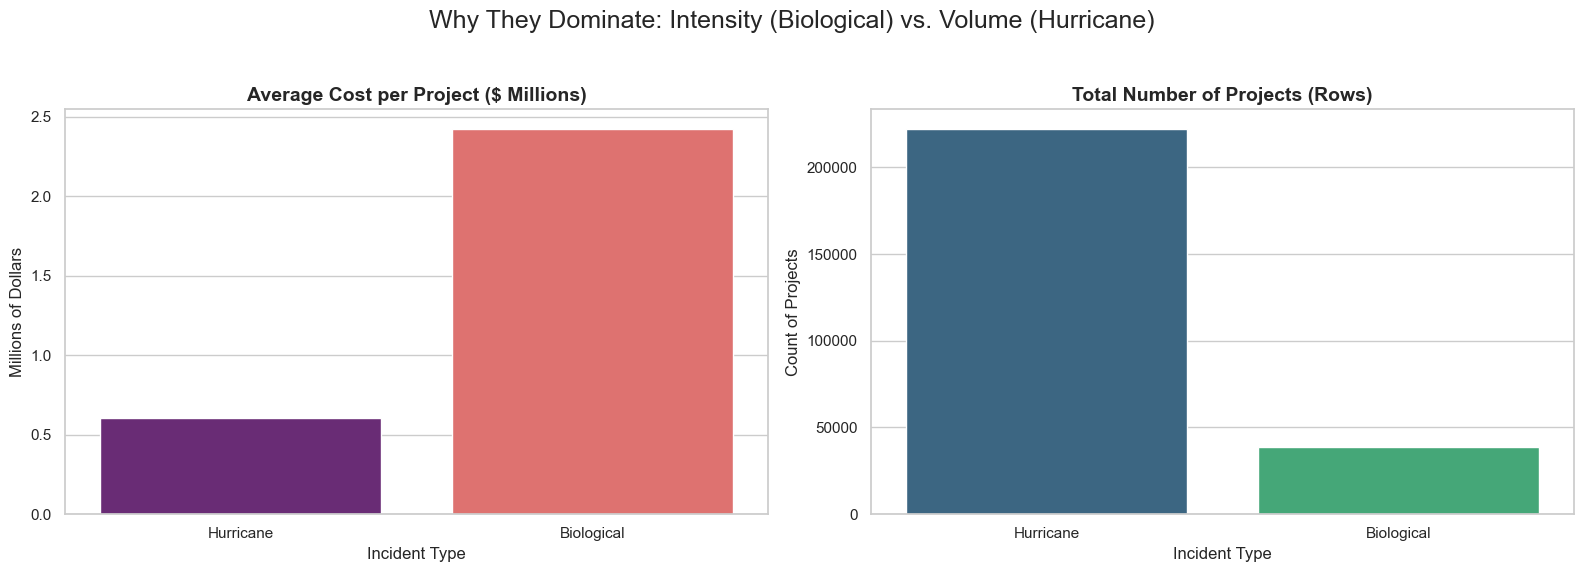

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate Intensity (Average Cost per Project Row)
avg_hurricane = df_final[df_final['incidentType'] == 'Hurricane']['totalObligated'].mean()
avg_biological = df_final[df_final['incidentType'] == 'Biological']['totalObligated'].mean()

avg_data = pd.DataFrame({
    'Incident Type': ['Hurricane', 'Biological'],
    'Avg_Project_Cost_M': [avg_hurricane / 1e6, avg_biological / 1e6] # Convert to Millions
})

# 2. Calculate Volume (Number of Project Rows)
count_data = df_final[df_final['incidentType'].isin(['Hurricane', 'Biological'])]['incidentType'].value_counts().reset_index()
count_data.columns = ['Incident Type', 'Project_Count']

# --- VISUALIZATION ---
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Average Project Intensity
sns.barplot(data=avg_data, x='Incident Type', y='Avg_Project_Cost_M', ax=ax[0], palette='magma')
ax[0].set_title('Average Cost per Project ($ Millions)', fontsize=14, fontweight='bold')
ax[0].set_ylabel('Millions of Dollars')

# Plot B: Project Volume
sns.barplot(data=count_data, x='Incident Type', y='Project_Count', ax=ax[1], palette='viridis')
ax[1].set_title('Total Number of Projects (Rows)', fontsize=14, fontweight='bold')
ax[1].set_ylabel('Count of Projects')

plt.suptitle('Why They Dominate: Intensity (Biological) vs. Volume (Hurricane)', fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


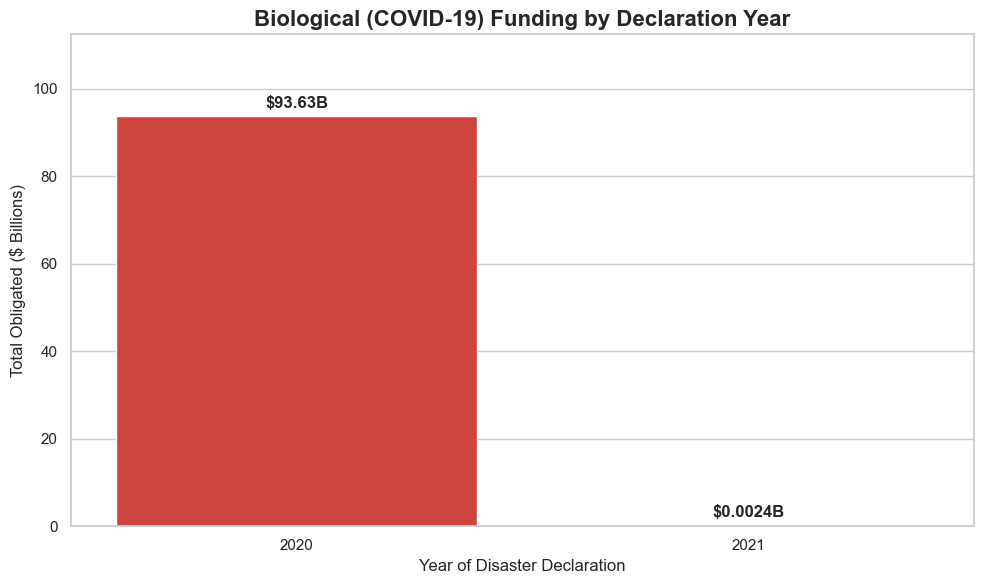

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Dynamic Data Fetching: Extract Year and calculate funding for 'Biological'
# We use .copy() to avoid SettingWithCopy warnings
df_bio = df_money[df_money['incidentType'] == 'Biological'].copy()
df_bio['year'] = pd.to_datetime(df_bio['declarationDate']).dt.year

# 2. Group by year and convert to Billions
# We reset_index() to turn the series back into a DataFrame for Seaborn
covid_summary = df_bio.groupby('year')['totalObligated'].sum().reset_index()
covid_summary['totalObligated'] = covid_summary['totalObligated'] / 1e9
covid_summary.columns = ['Year', 'Funding_Billions']

# --- VISUALIZATION ---
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Create the Bar Plot
ax = sns.barplot(data=covid_summary, x='Year', y='Funding_Billions', palette='Reds_r')

# Adding labels directly from the calculated data
for i, v in enumerate(covid_summary['Funding_Billions']):
    # Only label bars that have enough value to see (v > 0)
    label = f'${v:.2f}B' if v > 0.01 else f'${v:.4f}B'
    ax.text(i, v + 2, label, ha='center', fontweight='bold', fontsize=12)

plt.title('Biological (COVID-19) Funding by Declaration Year', fontsize=16, fontweight='bold')
plt.ylabel('Total Obligated ($ Billions)', fontsize=12)
plt.xlabel('Year of Disaster Declaration', fontsize=12)

# Dynamic headroom (max value + 20%)
plt.ylim(0, covid_summary['Funding_Billions'].max() * 1.2) 

plt.tight_layout()
plt.show()


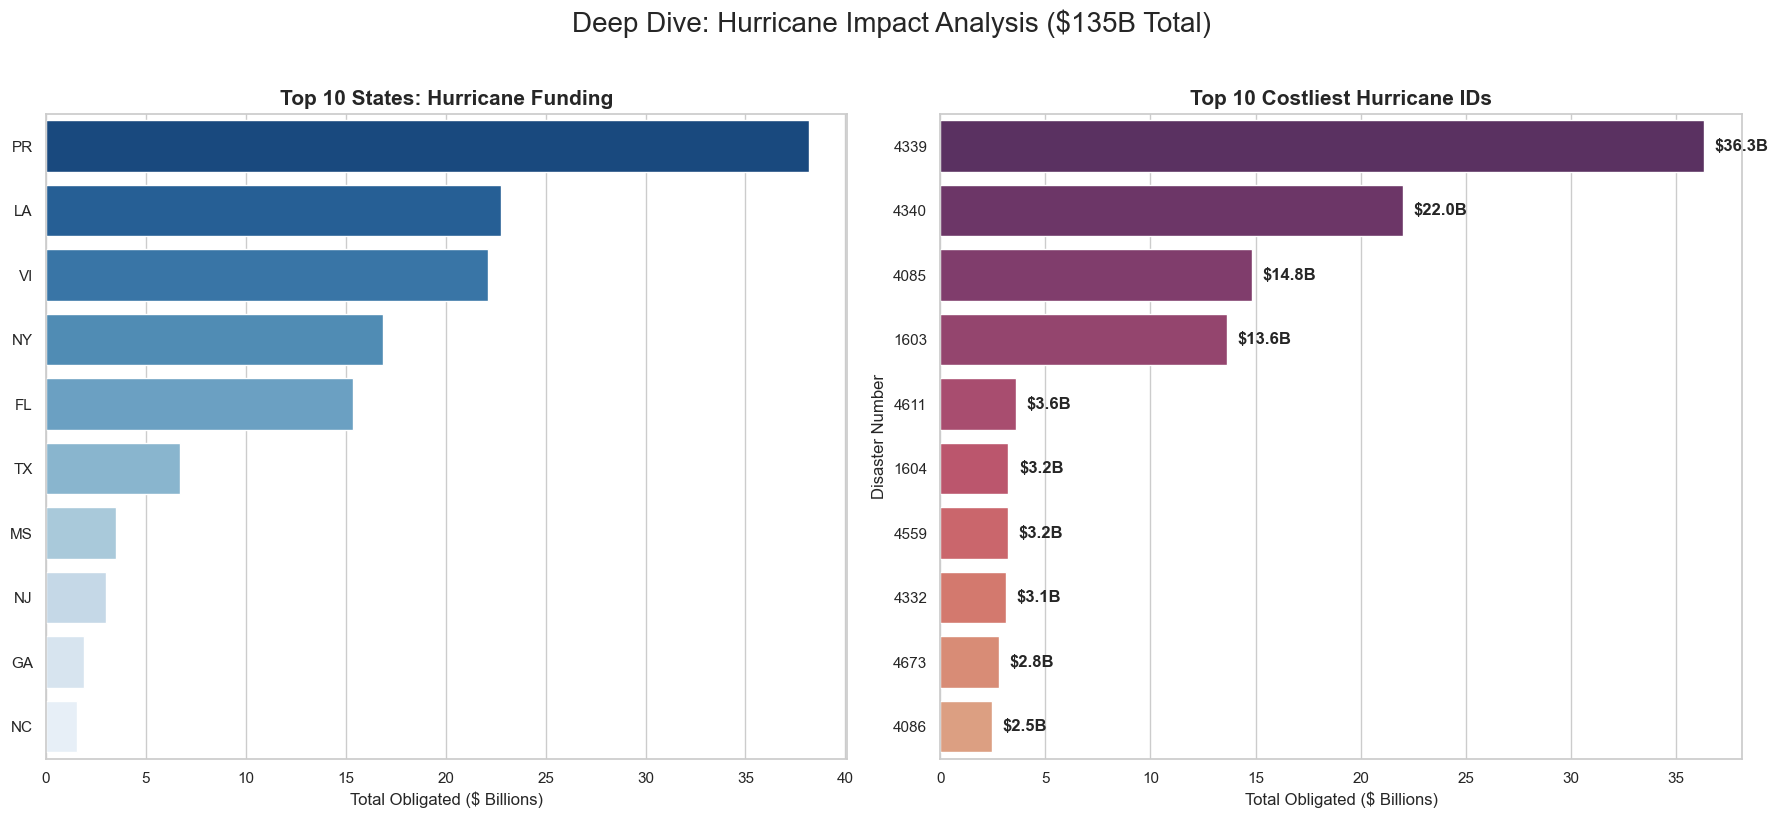

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Identify the Top Incident Type automatically
top_incident = df_final.groupby('incidentType')['totalObligated'].sum().idxmax()
df_top = df_final[df_final['incidentType'] == top_incident].copy()

# 2. Data Preparation: Top 10 States and Top 10 Specific Disasters for this type
state_data = (df_top.groupby('state')['totalObligated'].sum() / 1e9).sort_values(ascending=False).head(10)
disaster_data = (df_top.groupby('disasterNumber')['totalObligated'].sum() / 1e9).sort_values(ascending=False).head(10)

# --- VISUALIZATION ---
fig, ax = plt.subplots(1, 2, figsize=(18, 8))
sns.set_theme(style="whitegrid")

# Plot A: Top 10 States for Hurricanes
sns.barplot(x=state_data.values, y=state_data.index, ax=ax[0], palette='Blues_r')
ax[0].set_title(f'Top 10 States: {top_incident} Funding', fontsize=15, fontweight='bold')
ax[0].set_xlabel('Total Obligated ($ Billions)')
ax[0].set_ylabel('')

# Plot B: The "Catastrophic 10" (Specific Disaster IDs)
sns.barplot(x=disaster_data.values, y=disaster_data.index.astype(str), ax=ax[1], palette='flare_r')
ax[1].set_title(f'Top 10 Costliest {top_incident} IDs', fontsize=15, fontweight='bold')
ax[1].set_xlabel('Total Obligated ($ Billions)')
ax[1].set_ylabel('Disaster Number')

# Annotate with Billion Dollar labels
for i, v in enumerate(disaster_data.values):
    ax[1].text(v + 0.5, i, f'${v:.1f}B', va='center', fontweight='bold')

plt.suptitle(f'Deep Dive: {top_incident} Impact Analysis ($135B Total)', fontsize=20, y=1.02)
plt.tight_layout()
plt.show()


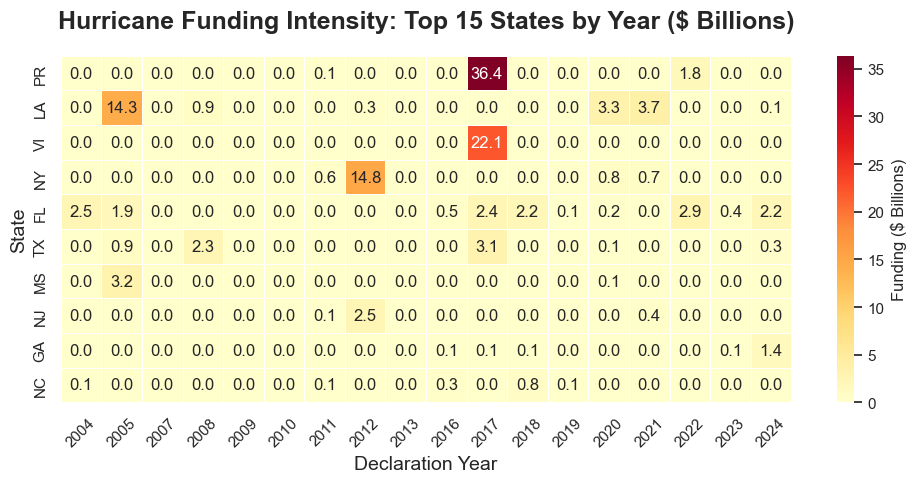

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter for Hurricane data only
df_hurricane = df_final[df_final['incidentType'] == 'Hurricane'].copy()

# 2. Prepare Temporal Data (Last 20 Years)
df_hurricane['year'] = pd.to_datetime(df_hurricane['declarationDate']).dt.year
hurricane_recent = df_hurricane[df_hurricane['year'] >= 2004]

# 3. Pivot: Rows = State, Columns = Year, Values = Sum of Funding (in Billions)
pivot_df = hurricane_recent.pivot_table(
    index='state', 
    columns='year', 
    values='totalObligated', 
    aggfunc='sum'
).fillna(0) / 1e9

# Sort states by total funding and take Top 15 for a clean visual
state_order = pivot_df.sum(axis=1).sort_values(ascending=False).index
pivot_df = pivot_df.reindex(state_order).head(10)

# --- VISUALISATION ---
plt.figure(figsize=(10, 5))
sns.set_theme(style="white")

# 'YlOrRd' (Yellow-Orange-Red) highlights the most expensive 'hot spots'
ax = sns.heatmap(pivot_df, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=.5, cbar_kws={'label': 'Funding ($ Billions)'})

plt.title('Hurricane Funding Intensity: Top 15 States by Year ($ Billions)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Declaration Year', fontsize=14)
plt.ylabel('State', fontsize=14)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


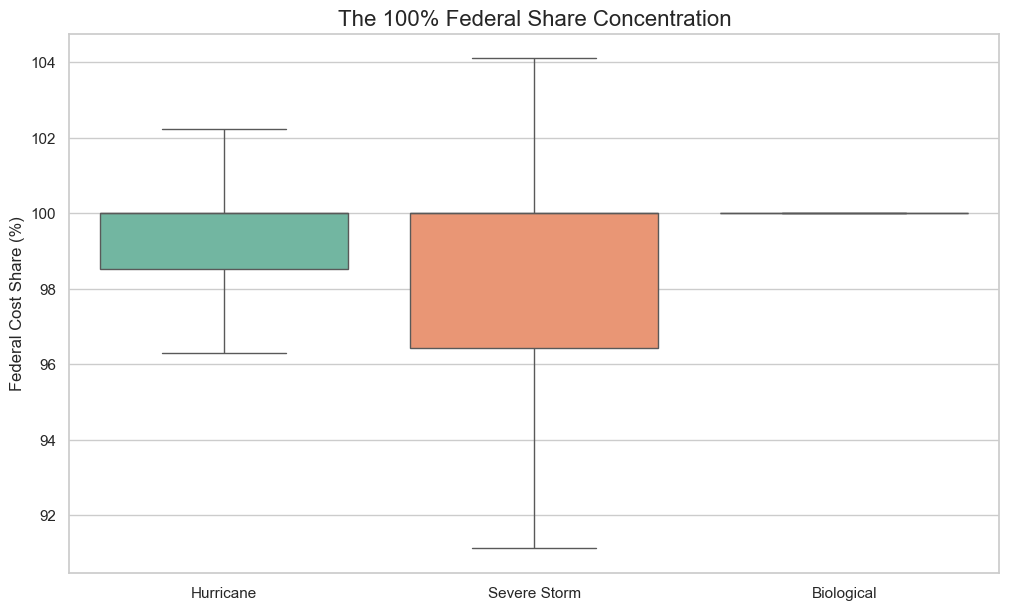

In [26]:
plt.figure(figsize=(12, 7))

# Filter for readable subset
top_3 = ['Hurricane', 'Biological', 'Severe Storm']
df_box = df_final[df_final['incidentType'].isin(top_3)].copy()
df_box['fed_share_pct'] = (df_box['federalShareObligated'] / df_box['totalObligated']) * 100

sns.boxplot(data=df_box, x='incidentType', y='fed_share_pct', palette='Set2', showfliers=False)
plt.title('The 100% Federal Share Concentration', fontsize=16)
plt.ylabel('Federal Cost Share (%)')
plt.xlabel('')
plt.show()


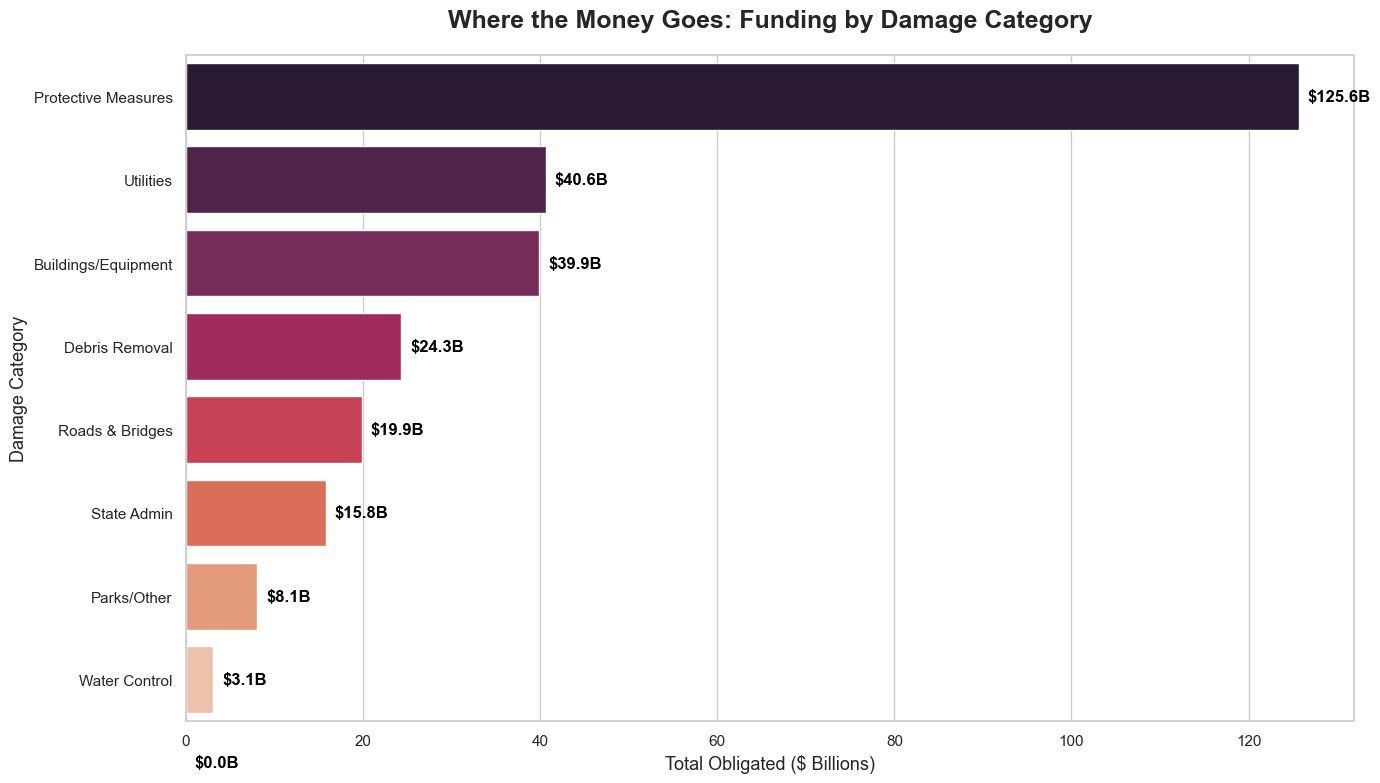

In [37]:

# 1. Map the Codes to Human-Readable Labels
category_map = {
    'A': 'Debris Removal',
    'B': 'Protective Measures',
    'C': 'Roads & Bridges',
    'D': 'Water Control',
    'E': 'Buildings/Equipment',
    'F': 'Utilities',
    'G': 'Parks/Other',
    'Z': 'State Admin'
}

# 2. Prepare Data (Billions)
damage_summary = (df_final.groupby('damageCategoryCode')['totalObligated'].sum() / 1e9).reset_index()
damage_summary['Category_Name'] = damage_summary['damageCategoryCode'].map(category_map)
damage_summary = damage_summary.sort_values('totalObligated', ascending=False)

# --- VISUALIZATION ---
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

# Create Bar Plot
ax = sns.barplot(data=damage_summary, x='totalObligated', y='Category_Name', palette='rocket')

# Add $B labels
for i, v in enumerate(damage_summary['totalObligated']):
    ax.text(v + 1, i, f'${v:.1f}B', va='center', fontweight='bold', color='black')

plt.title('Where the Money Goes: Funding by Damage Category', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Total Obligated ($ Billions)', fontsize=13)
plt.ylabel('Damage Category', fontsize=13)

plt.tight_layout()
plt.show()


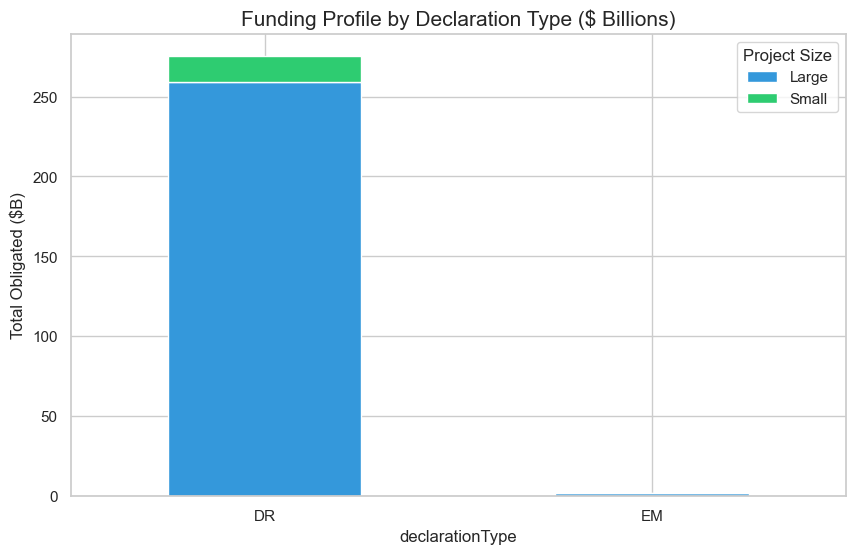

In [41]:
# Aggregate funding by Type and Project Size
decl_profile = df_final.groupby(['declarationType', 'projectSize'])['totalObligated'].sum().unstack().fillna(0) / 1e9

decl_profile.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#3498db', '#2ecc71'])
plt.title('Funding Profile by Declaration Type ($ Billions)', fontsize=15)
plt.ylabel('Total Obligated ($B)')
plt.xticks(rotation=0)
plt.legend(title='Project Size')
plt.show()


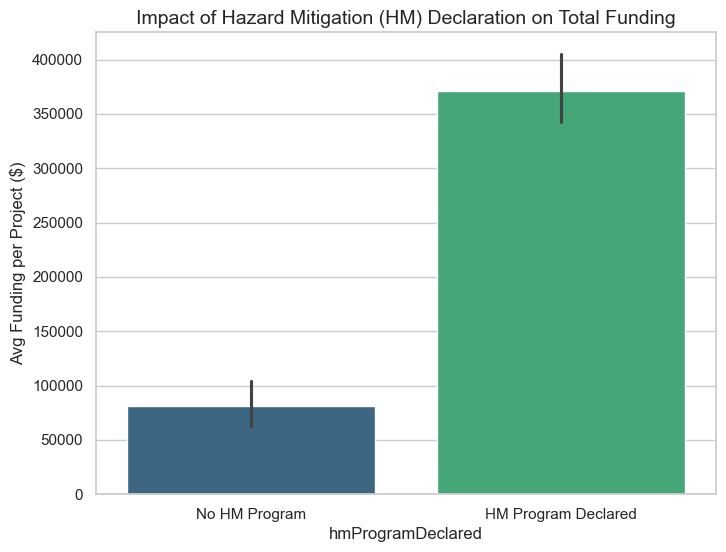

In [42]:
# Compare average totalObligated for HM Declared (1) vs Not (0)
plt.figure(figsize=(8, 6))
sns.barplot(data=df_final, x='hmProgramDeclared', y='totalObligated', palette='viridis')
plt.title('Impact of Hazard Mitigation (HM) Declaration on Total Funding', fontsize=14)
plt.xticks([0, 1], ['No HM Program', 'HM Program Declared'])
plt.ylabel('Avg Funding per Project ($)')
plt.show()


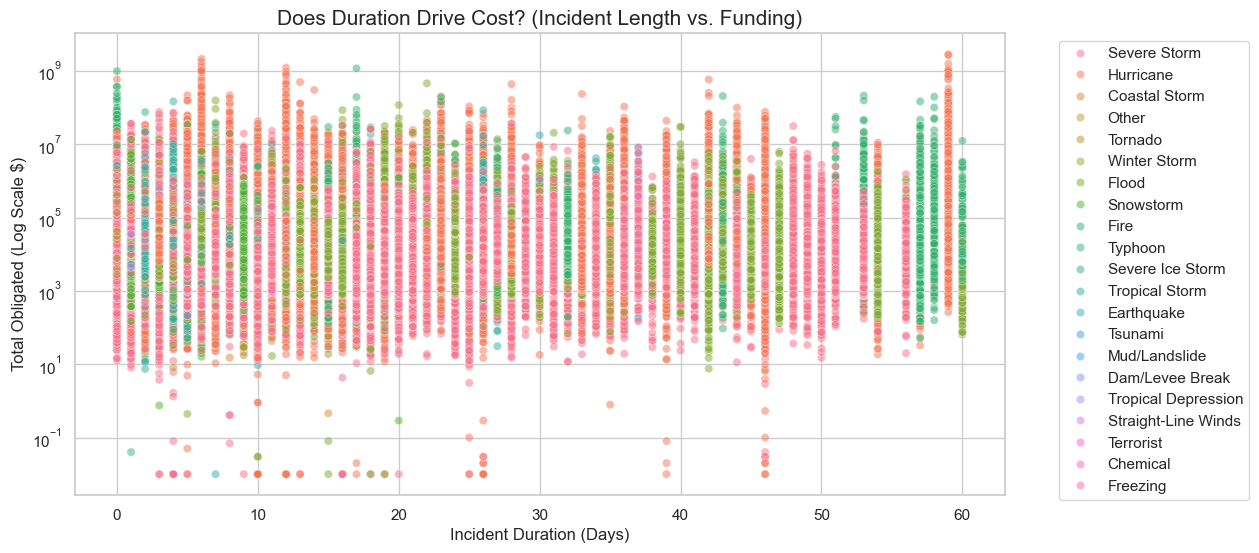

In [43]:
# 1. Calculate Incident Duration
df_final['incidentEndDate'] = pd.to_datetime(df_final['incidentEndDate'])
df_final['incident_duration'] = (df_final['incidentEndDate'] - df_final['incidentBeginDate']).dt.days

# 2. Filter for reasonable durations (ignore outliers like multi-year droughts for better visual)
df_dur = df_final[(df_final['incident_duration'] >= 0) & (df_final['incident_duration'] <= 60)]

plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_dur, x='incident_duration', y='totalObligated', hue='incidentType', alpha=0.5)
plt.yscale('log') # Log scale because project costs vary by millions
plt.title('Does Duration Drive Cost? (Incident Length vs. Funding)', fontsize=15)
plt.xlabel('Incident Duration (Days)')
plt.ylabel('Total Obligated (Log Scale $)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


In [10]:
df_decl_clean['disasterNumber'].duplicated().sum()

np.int64(1167)

In [9]:
# Check if 'state' exists in both (it likely does)
# If the merge added a suffix (like state_x and state_y), let's compare them
state_cols = [c for c in df_merged.columns if 'state' in c.lower()]

if len(state_cols) >= 2:
    mismatch = df_merged[df_merged[state_cols[0]] != df_merged[state_cols[1]]]
    print(f"Number of rows where states don't match: {len(mismatch)}")
    if len(mismatch) > 0:
        print(mismatch[state_cols].head(20))
else:
    print("Only one state column found; no mismatch to check.")


Number of rows where states don't match: 784935
    stateNumberCode state stateNumberCode_str state_mapped
0                22    LA                  22           LA
1                 4    AZ                  04           AZ
2                 4    AZ                  04           AZ
3                72    PR                  72           PR
4                72    PR                  72           PR
5                72    PR                  72           PR
6                72    PR                  72           PR
7                72    PR                  72           PR
8                72    PR                  72           PR
9                48    TX                  48           TX
10               72    PR                  72           PR
11               72    PR                  72           PR
12               72    PR                  72           PR
13               72    PR                  72           PR
14               72    PR                  72           PR
15      

In [ ]:
df_decl.head()

,disasterNumber,state,designatedArea,incidentType,declarationDate,incidentBeginDate,incidentEndDate,declarationType
0,5529,OR,Washington (County),Fire,2024-08-09T00:00:00.000Z,2024-08-08T00:00:00.000Z,NaN,FM
1,5528,OR,Jefferson (County),Fire,2024-08-06T00:00:00.000Z,2024-08-04T00:00:00.000Z,NaN,FM
2,5527,OR,Deschutes (County),Fire,2024-08-02T00:00:00.000Z,2024-08-02T00:00:00.000Z,NaN,FM
3,4312,CA,Resighini Rancheria (Indian Reservation),Severe Storm,2017-05-02T00:00:00.000Z,2017-02-08T00:00:00.000Z,2017-02-11T00:00:00.000Z,DR
4,4251,AL,Autauga (County),Severe Storm,2016-01-21T00:00:00.000Z,2015-12-23T00:00:00.000Z,2015-12-31T00:00:00.000Z,DR


In [20]:
declarations.info()

<class 'pandas.DataFrame'>
RangeIndex: 69769 entries, 0 to 69768
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   disasterNumber     69769 non-null  int64
 1   state              69769 non-null  str  
 2   designatedArea     69769 non-null  str  
 3   incidentType       69769 non-null  str  
 4   declarationDate    69769 non-null  str  
 5   incidentBeginDate  69769 non-null  str  
 6   incidentEndDate    69232 non-null  str  
 7   declarationType    69769 non-null  str  
dtypes: int64(1), str(7)
memory usage: 4.3 MB


In [21]:
declarations.isna().sum()

disasterNumber         0
state                  0
designatedArea         0
incidentType           0
declarationDate        0
incidentBeginDate      0
incidentEndDate      537
declarationType        0
dtype: int64

In [22]:
declarations = declarations.dropna(subset=['incidentEndDate'])
declarations.info()

<class 'pandas.DataFrame'>
Index: 69232 entries, 3 to 69768
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   disasterNumber     69232 non-null  int64
 1   state              69232 non-null  str  
 2   designatedArea     69232 non-null  str  
 3   incidentType       69232 non-null  str  
 4   declarationDate    69232 non-null  str  
 5   incidentBeginDate  69232 non-null  str  
 6   incidentEndDate    69232 non-null  str  
 7   declarationType    69232 non-null  str  
dtypes: int64(1), str(7)
memory usage: 4.8 MB


In [23]:
declarations.duplicated().sum()

np.int64(28)

In [24]:
declarations = declarations.drop_duplicates()
len(declarations)

69204

In [4]:
df_decl.nunique()

disasterNumber       5163
state                  59
designatedArea       2960
incidentType           27
declarationDate      3585
incidentBeginDate    3290
incidentEndDate      3350
declarationType         3
dtype: int64

In [31]:
declarations['declarationDate'] = pd.to_datetime(declarations['declarationDate'])
declarations['incidentBeginDate'] = pd.to_datetime(declarations['incidentBeginDate'])
declarations['incidentEndDate'] = pd.to_datetime(declarations['incidentEndDate'])

In [ ]:
declarations.describe(include=['object'])


,state,designatedArea,incidentType,declarationType
count,69204,69204,69204,69204
unique,59,2960,27,3
top,TX,Washington (County),Severe Storm,DR
freq,5352,591,19299,46198


In [35]:
categorical_cols = declarations.select_dtypes(include=['object', 'category']).columns.to_list()
for col in categorical_cols:
    print(f'{declarations[col].value_counts()}\n')

state
TX    5352
KY    3325
MO    2830
GA    2757
VA    2753
LA    2670
FL    2657
OK    2529
NC    2421
MS    2129
PR    2116
TN    2021
IA    1926
KS    1909
AR    1824
AL    1734
MN    1623
CA    1612
IN    1581
NE    1580
NY    1537
SD    1453
ND    1423
WV    1336
IL    1313
OH    1292
PA    1252
SC    1182
ME    1059
WA    1007
WI     895
MI     819
CO     661
NJ     624
MT     620
OR     614
NM     517
MD     471
MA     414
VT     405
ID     370
AK     352
AZ     335
NH     320
NV     283
CT     264
UT     255
WY     132
RI     123
HI     104
VI      87
MP      76
AS      76
DE      53
MH      53
FM      31
DC      24
GU      22
PW       1
Name: count, dtype: int64

designatedArea
Washington (County)                       591
Jefferson (County)                        534
Jackson (County)                          514
Franklin (County)                         511
Statewide                                 462
                                         ... 
Kipnuk (ANV/ANVSA)         

## Exploratory Data Analysis

#### Incident Type Distribution (Frequency)

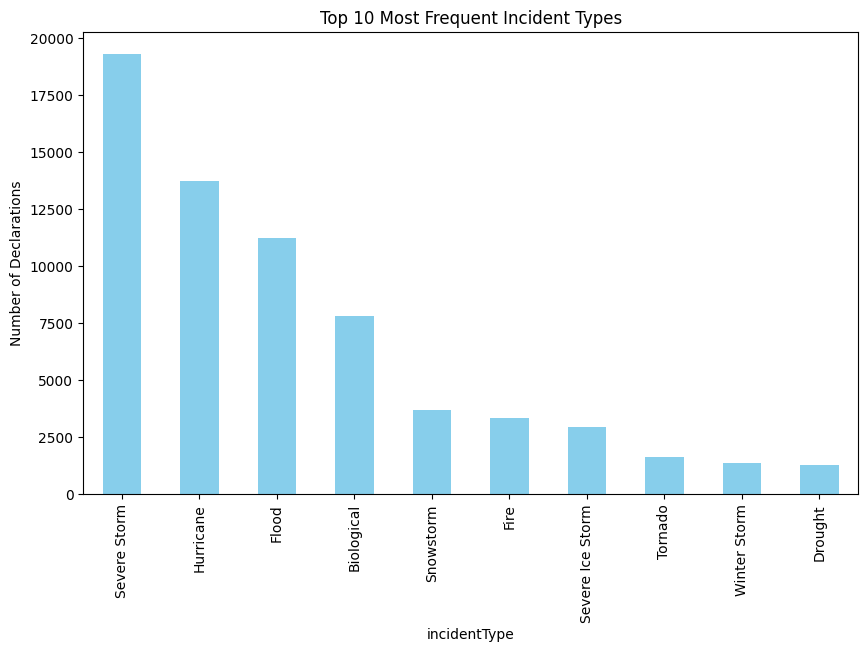

In [37]:
plt.figure(figsize=(10,6))
declarations['incidentType'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 Most Frequent Incident Types')
plt.ylabel('Number of Declarations')
plt.show()

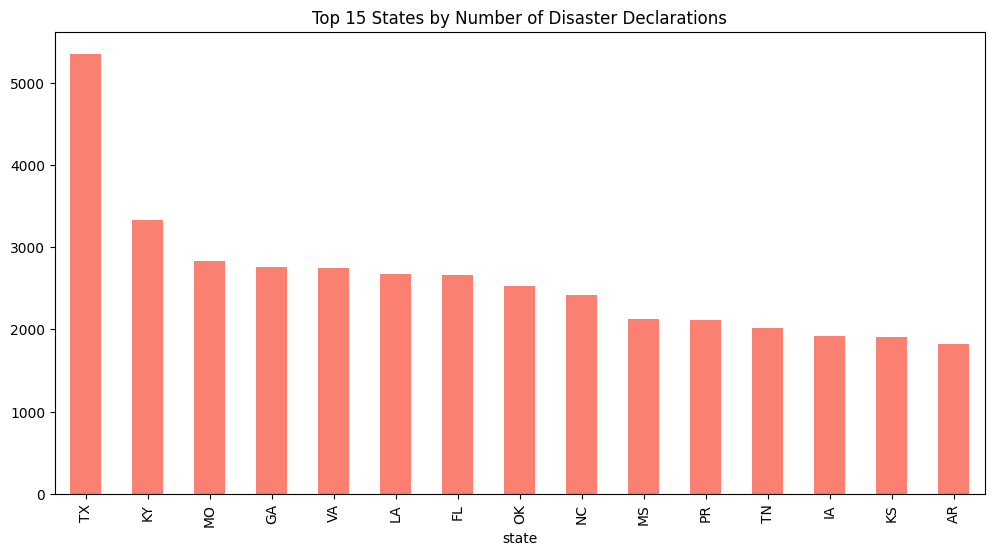

In [38]:
plt.figure(figsize=(12,6))
declarations['state'].value_counts().head(15).plot(kind='bar', color='salmon')
plt.title('Top 15 States by Number of Disaster Declarations')
plt.show()

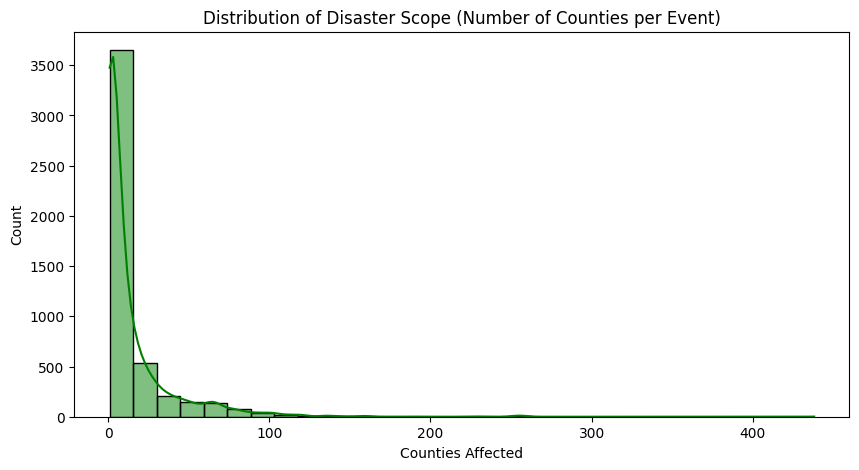

In [39]:
# Group by disaster to see the count of areas hit
scope_df = declarations.groupby('disasterNumber')['designatedArea'].nunique().reset_index()

plt.figure(figsize=(10,5))
sns.histplot(scope_df['designatedArea'], bins=30, kde=True, color='green')
plt.title('Distribution of Disaster Scope (Number of Counties per Event)')
plt.xlabel('Counties Affected')
plt.show()

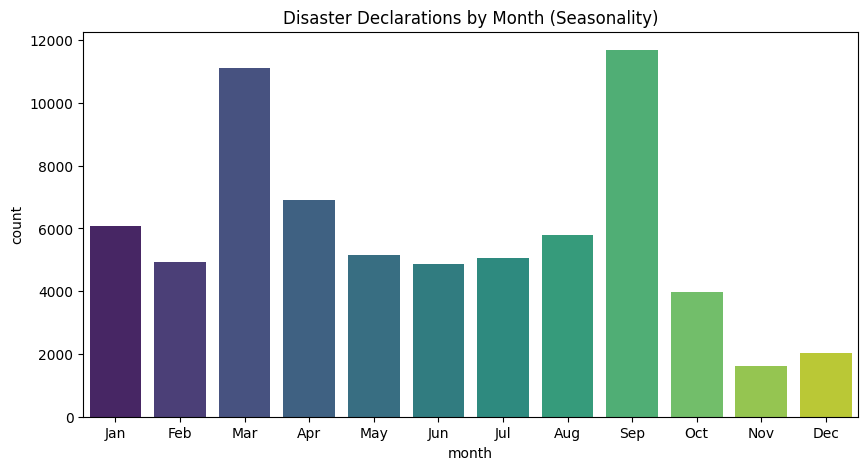

In [40]:
# Convert to datetime and extract month
declarations['declarationDate'] = pd.to_datetime(declarations['declarationDate'])
declarations['month'] = declarations['declarationDate'].dt.month

plt.figure(figsize=(10,5))
sns.countplot(x='month', data=declarations, palette='viridis')
plt.title('Disaster Declarations by Month (Seasonality)')
plt.xticks(ticks=range(0,12), labels=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.show()

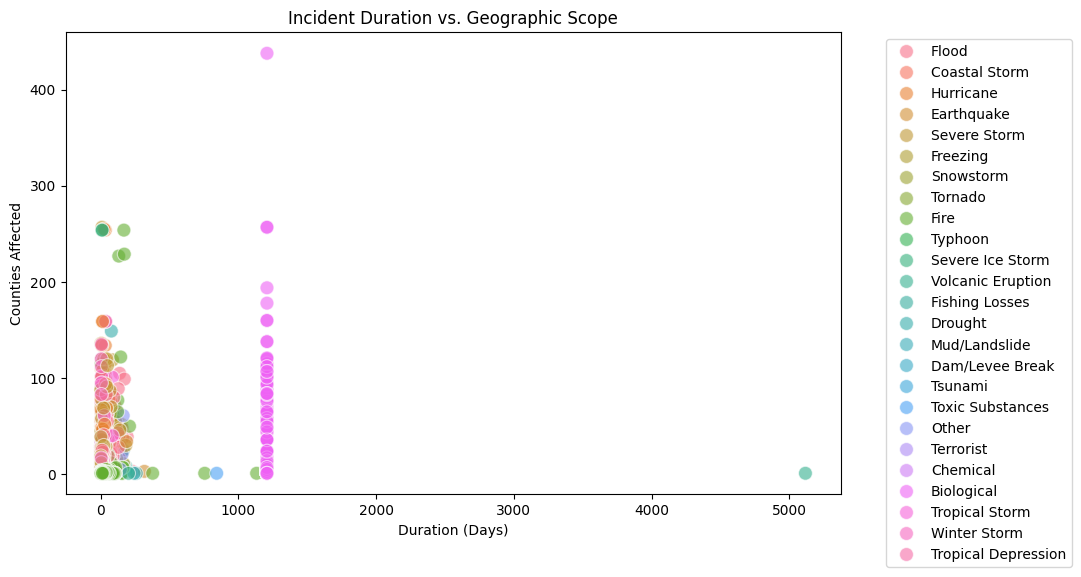

In [41]:
# Calculate Duration and Scope
declarations['duration'] = (pd.to_datetime(declarations['incidentEndDate']) - 
                            pd.to_datetime(declarations['incidentBeginDate'])).dt.days

corr_df = declarations.groupby(['disasterNumber', 'incidentType']).agg({
    'duration': 'max',
    'designatedArea': 'nunique'
}).reset_index()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=corr_df[corr_df['duration'] > 0], x='duration', y='designatedArea', 
                hue='incidentType', alpha=0.6, s=100)
plt.title('Incident Duration vs. Geographic Scope')
plt.xlabel('Duration (Days)')
plt.ylabel('Counties Affected')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()


In [5]:
pub_ass_funding

,disasterNumber,incidentType,damageCategoryCode,stateNumberCode,gmProjectId,countyCode,projectAmount,federalShareObligated,totalObligated
0,1603,Hurricane,E,22,901765,75,18602329.78,18602329.78,18788818.15
1,1586,Severe Storm(s),G,4,899650,5,112090.72,84068.04,88196.37
2,1586,Severe Storm(s),G,4,899657,5,773645.98,580234.49,603034.89
3,3384,Hurricane,B,72,51291,3,59779.98,44834.99,44834.99
4,3384,Hurricane,B,72,55081,57,20333.13,15249.85,15249.85
...,...,...,...,...,...,...,...,...,...
784930,4834,Hurricane,Z,12,966806,115,2961.45,2961.45,2961.45
784931,4878,Severe Storm(s),C,47,961633,71,58239.38,43679.54,43679.54
784932,4879,Flood,F,48,961529,435,104057.32,78042.99,78042.99
784933,4881,Flood,B,41,966133,11,1093.20,819.91,819.91


In [6]:
pub_ass_funding.nunique()

disasterNumber             1707
incidentType                 26
damageCategoryCode            9
stateNumberCode              57
gmProjectId              784935
countyCode                  325
projectAmount            642130
federalShareObligated    638146
totalObligated           667041
dtype: int64